1.1. Cargar una imagen se debe utilizar para lo que es lo siguiente.

In [10]:
!wget https://assets.datacamp.com/production/repositories/2085/datasets/f44726fefae841afd24ddf83c58f34722212e67a/tcia-chest-ct-sample.zip


--2025-10-09 17:00:38--  https://assets.datacamp.com/production/repositories/2085/datasets/f44726fefae841afd24ddf83c58f34722212e67a/tcia-chest-ct-sample.zip
Resolviendo assets.datacamp.com (assets.datacamp.com)... 104.18.43.162, 172.64.144.94
Conectando con assets.datacamp.com (assets.datacamp.com)[104.18.43.162]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 1141220 (1,1M)
Guardando como: ‘tcia-chest-ct-sample.zip’

tcia-chest-ct-sampl 100%[===================>]   1,09M   403KB/s    en 2,8s    

2025-10-09 17:00:41 (403 KB/s) - ‘tcia-chest-ct-sample.zip’ guardado [1141220/1141220]



In [9]:
import zipfile
with zipfile.ZipFile("tcia-chest-ct-sample.zip", 'r') as zip_ref:
    zip_ref.extractall("imagenes_ct")

In [10]:
# Importar imageio
import imageio.v2 as imageio
# Leer la imagen DICOM
im = imageio.imread('imagenes_ct/chest-220.dcm')
# Mostrar tipo y dimensiones de la imagen
print('Image type:', type(im))
print('Shape of image array:', im.shape)

Image type: <class 'imageio.core.util.Array'>
Shape of image array: (512, 512)


In [11]:
print(im.meta.keys())


odict_keys(['TransferSyntaxUID', 'SOPClassUID', 'SOPInstanceUID', 'StudyDate', 'SeriesDate', 'ContentDate', 'StudyTime', 'SeriesTime', 'ContentTime', 'Modality', 'Manufacturer', 'StudyDescription', 'SeriesDescription', 'PatientName', 'PatientID', 'PatientBirthDate', 'PatientSex', 'PatientWeight', 'StudyInstanceUID', 'SeriesInstanceUID', 'SeriesNumber', 'AcquisitionNumber', 'InstanceNumber', 'ImagePositionPatient', 'ImageOrientationPatient', 'SamplesPerPixel', 'Rows', 'Columns', 'PixelSpacing', 'BitsAllocated', 'BitsStored', 'HighBit', 'PixelRepresentation', 'RescaleIntercept', 'RescaleSlope', 'PixelData', 'shape', 'sampling'])


In [12]:
# Imprimir los metadatos disponibles
print(im.meta)

Dict([('TransferSyntaxUID', '1.2.840.10008.1.2'), ('SOPClassUID', '1.2.840.10008.5.1.4.1.1.2'), ('SOPInstanceUID', '1.3.6.1.4.1.14519.5.2.1.5168.1900.290866807370146801046392918286'), ('StudyDate', '20040529'), ('SeriesDate', '20040515'), ('ContentDate', '20040515'), ('StudyTime', '115208'), ('SeriesTime', '115254'), ('ContentTime', '115325'), ('Modality', 'CT'), ('Manufacturer', 'GE MEDICAL SYSTEMS'), ('StudyDescription', 'PET CT with registered MR'), ('SeriesDescription', 'CT IMAGES - RESEARCH'), ('PatientName', 'STS_007'), ('PatientID', 'STS_007'), ('PatientBirthDate', ''), ('PatientSex', 'F '), ('PatientWeight', 82.0), ('StudyInstanceUID', '1.3.6.1.4.1.14519.5.2.1.5168.1900.381397737790414481604846607090'), ('SeriesInstanceUID', '1.3.6.1.4.1.14519.5.2.1.5168.1900.315477836840324582280843038439'), ('SeriesNumber', 2), ('AcquisitionNumber', 1), ('InstanceNumber', 57), ('ImagePositionPatient', (-250.0, -250.0, -180.62)), ('ImageOrientationPatient', (1.0, 0.0, 0.0, 0.0, 1.0, 0.0)), ('S

In [13]:
import matplotlib.pyplot as plt

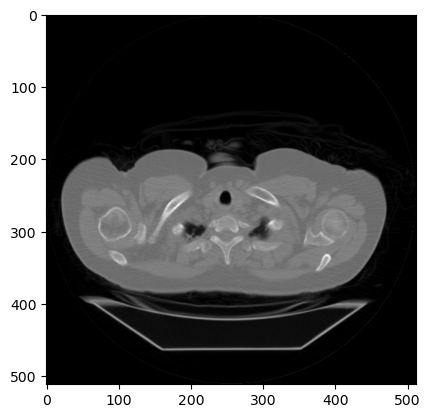

In [14]:
plt.imshow(im, cmap="gray")

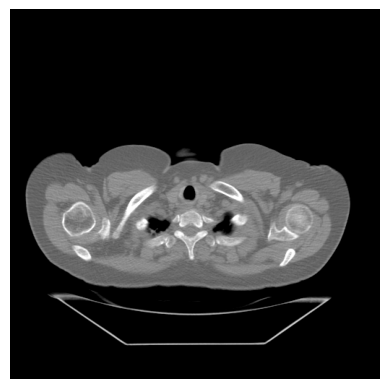

In [26]:
# Dibujar la imagen con mayor contraste
plt.imshow(im,cmap="gray",vmin=-500, vmax=500)
# Quitar los ejes y etiquetas
plt.axis('off')
# Renderiza la imagen
plt.show()

In [15]:
import numpy as np
# Read in each 2D image
im1 = imageio.imread('imagenes_ct/chest-220.dcm')
im2 = imageio.imread('imagenes_ct/chest-221.dcm')
im3 = imageio.imread('imagenes_ct/chest-222.dcm')
# Stack images into a volume
vol = np.stack([im1,im2,im3], axis=0)
print('Volume dimensions:', vol.shape)

Volume dimensions: (3, 512, 512)


In [16]:
# specify directory and file pattern
foldername = 'imagenes_ct'
pattern = '*.dcm'
# Load the "Data" directory
vol = imageio.volread(foldername, pattern)
# Print image attributes
print('Available metadata:', vol.meta.keys())
print('Shape of image array:', vol.shape)

Reading DICOM (examining files): 5/5 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 5/5  (100.0%)
Available metadata: odict_keys(['TransferSyntaxUID', 'SOPClassUID', 'SOPInstanceUID', 'StudyDate', 'SeriesDate', 'ContentDate', 'StudyTime', 'SeriesTime', 'ContentTime', 'Modality', 'Manufacturer', 'StudyDescription', 'SeriesDescription', 'PatientName', 'PatientID', 'PatientBirthDate', 'PatientSex', 'PatientWeight', 'StudyInstanceUID', 'SeriesInstanceUID', 'SeriesNumber', 'AcquisitionNumber', 'InstanceNumber', 'ImagePositionPatient', 'ImageOrientationPatient', 'SamplesPerPixel', 'Rows', 'Columns', 'PixelSpacing', 'BitsAllocated', 'BitsStored', 'HighBit', 'PixelRepresentation', 'RescaleIntercept', 'RescaleSlope', 'PixelData', 'shape', 'sampling'])
Shape of image array: (5, 512, 512)


In [17]:
vol.shape

(5, 512, 512)

In [18]:
vol.meta['sampling']

(3.269999999999996, 0.976562, 0.976562)

In [19]:
import numpy as np
shape = np.array(vol.shape)
spacing = np.array(vol.meta['sampling'])
fov = shape * spacing
print("FOV (mm):", fov)

FOV (mm): [ 16.35     499.999744 499.999744]


Procesamiento de Imagenes P2, continuando con lo anterior establecido

In [20]:
# specify directory and file pattern
foldername = 'imagenes_ct'
pattern = '*.dcm'
# Load the "Data" directory
vol = imageio.volread(foldername, pattern)
# Print image attributes
print('Available metadata:', vol.meta.keys())
print('Shape of image array:', vol.shape)

Reading DICOM (examining files): 5/5 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 5/5  (100.0%)
Available metadata: odict_keys(['TransferSyntaxUID', 'SOPClassUID', 'SOPInstanceUID', 'StudyDate', 'SeriesDate', 'ContentDate', 'StudyTime', 'SeriesTime', 'ContentTime', 'Modality', 'Manufacturer', 'StudyDescription', 'SeriesDescription', 'PatientName', 'PatientID', 'PatientBirthDate', 'PatientSex', 'PatientWeight', 'StudyInstanceUID', 'SeriesInstanceUID', 'SeriesNumber', 'AcquisitionNumber', 'InstanceNumber', 'ImagePositionPatient', 'ImageOrientationPatient', 'SamplesPerPixel', 'Rows', 'Columns', 'PixelSpacing', 'BitsAllocated', 'BitsStored', 'HighBit', 'PixelRepresentation', 'RescaleIntercept', 'RescaleSlope', 'PixelData', 'shape', 'sampling'])
Shape of image array: (5, 512, 512)


In [21]:
vol.shape

(5, 512, 512)

In [22]:
vol.meta['sampling']

(3.269999999999996, 0.976562, 0.976562)

In [24]:
import numpy as np
shape = np.array(vol.shape)
spacing = np.array(vol.meta['sampling'])
fov = shape * spacing
print("FOV (mm):", fov)

FOV (mm): [ 16.35     499.999744 499.999744]


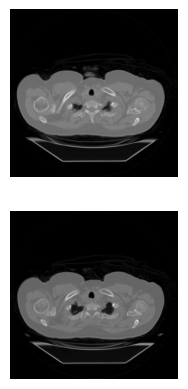

In [25]:
# Initialize figure and axes grid
fig, axes = plt.subplots(nrows=2, ncols=1)
# Draw an image on each subplot
axes[0].imshow(im1, cmap='gray')
axes[1].imshow(im2, cmap='gray')
# Remove ticks/labels and render
axes[0].axis('off')
axes[1].axis('off')
plt.show()

Available metadata: odict_keys(['TransferSyntaxUID', 'SOPClassUID', 'SOPInstanceUID', 'StudyDate', 'SeriesDate', 'ContentDate', 'StudyTime', 'SeriesTime', 'ContentTime', 'Modality', 'Manufacturer', 'StudyDescription', 'SeriesDescription', 'PatientName', 'PatientID', 'PatientBirthDate', 'PatientSex', 'PatientWeight', 'StudyInstanceUID', 'SeriesInstanceUID', 'SeriesNumber', 'AcquisitionNumber', 'InstanceNumber', 'ImagePositionPatient', 'ImageOrientationPatient', 'SamplesPerPixel', 'Rows', 'Columns', 'PixelSpacing', 'BitsAllocated', 'BitsStored', 'HighBit', 'PixelRepresentation', 'RescaleIntercept', 'RescaleSlope', 'PixelData', 'shape', 'sampling'])
Shape of image array: (5, 512, 512)


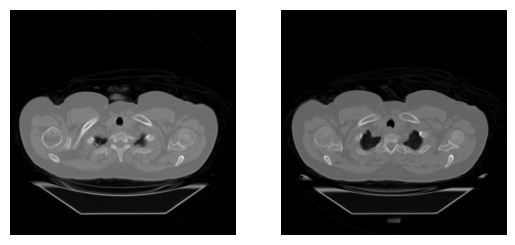

In [27]:
# Print image attributes
print('Available metadata:', vol.meta.keys())
print('Shape of image array:', vol.shape)

# Plot the images on a subplots array
fig, axes = plt.subplots(nrows=1, ncols=2)

# Loop through subplots and draw image
for ii in range(2):
    im = vol[ii*2, :, :]
    axes[ii].imshow(im, cmap='gray')
    axes[ii].axis('off')

# Render the figure
plt.show()

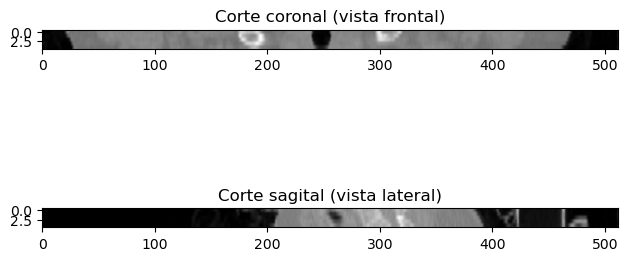

In [29]:
import matplotlib.pyplot as plt

# Seleccionamos cortes específicos del volumen "vol"
# vol tiene forma (n_cortes, alto, ancho)
# Ejes: 0 = profundidad (cortes), 1 = alto, 2 = ancho

# Corte CORONAL: se fija el índice 256 en el eje vertical (1)
# Muestra una vista de frente del cuerpo
im1 = vol[:, 256, :]

# Corte SAGITAL: se fija el índice 256 en el eje horizontal (2)
# Muestra una vista lateral del cuerpo
im2 = vol[:, :, 256]

# -----------------------------------------------------------
# Ajuste de la relación de aspecto (aspect ratio)
# para representar correctamente las proporciones físicas de los vóxeles en milímetros.
# -----------------------------------------------------------

# Obtenemos el tamaño real de los vóxeles desde los metadatos
# (d0: espaciado entre cortes, d1: tamaño píxel vertical, d2: tamaño píxel horizontal)
d0, d1, d2 = vol.meta['sampling']

# Calculamos las proporciones de aspecto para cada plano
# (para evitar que las imágenes se vean estiradas o comprimidas)
asp1 = d0 / d2  # relación para el plano coronal (profundidad vs ancho)
asp2 = d0 / d1  # relación para el plano sagital (profundidad vs alto)

# -----------------------------------------------------------
# Visualización de los dos cortes en una figura
# -----------------------------------------------------------

# Creamos una figura con 2 subgráficos (uno encima del otro)
fig, axes = plt.subplots(nrows=2, ncols=1)

# Mostramos el corte coronal
axes[0].imshow(im1, cmap='gray', aspect=asp1)
axes[0].set_title('Corte coronal (vista frontal)')
#axes[0].axis('off')

# Mostramos el corte sagital
axes[1].imshow(im2, cmap='gray', aspect=asp2)
axes[1].set_title('Corte sagital (vista lateral)')
#axes[1].axis('off')

# Mostramos ambas imágenes
plt.tight_layout()
plt.show()

In [ ]:
El ejercicio que aumenta el corte axial se usara en la generacion de cortes m1 y m2

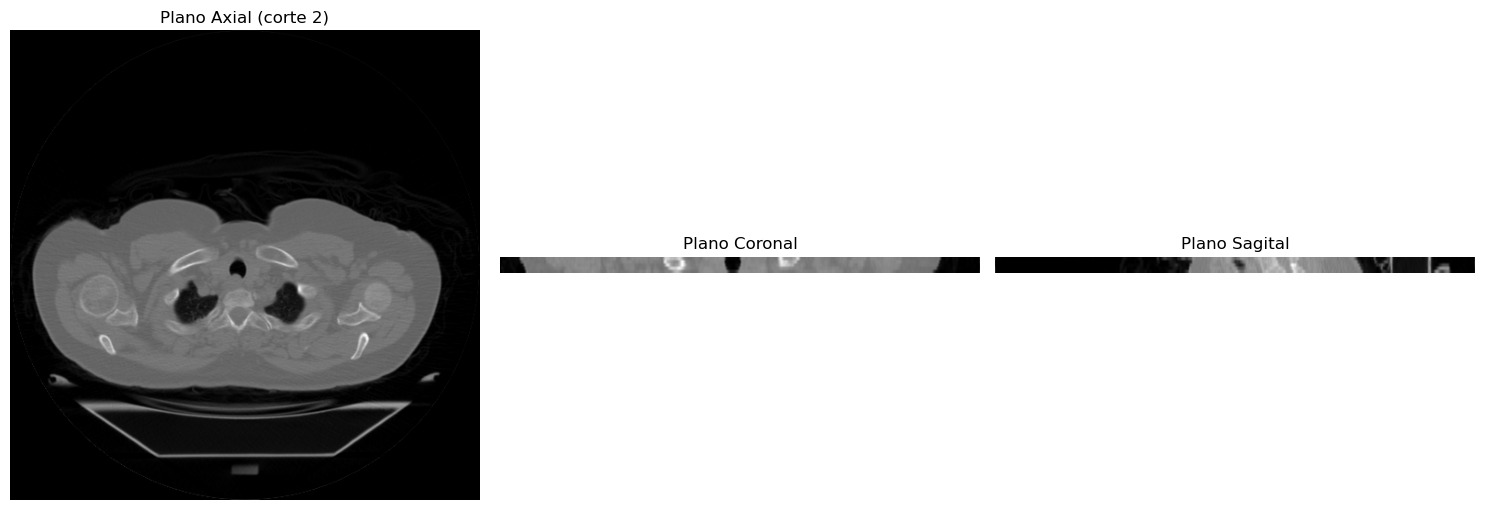

In [30]:
# -----------------------------------------------------------
# PUNTO ADICIONAL: Agregar el tercer plano (AXIAL)
# -----------------------------------------------------------

# Corte AXIAL: se fija el índice en el eje de profundidad (0)
# Muestra una vista desde arriba (corte horizontal)
z = 2  # Puedes cambiar este índice para explorar otros cortes
im_axial = vol[z, :, :]

# -----------------------------------------------------------
# Obtener el espaciado de los vóxeles
# -----------------------------------------------------------
d0, d1, d2 = vol.meta['sampling']

# Calcular aspect ratio para los tres planos
asp_axial = d1 / d2      # Plano axial: alto vs ancho
asp_coronal = d0 / d2    # Plano coronal (asp1 que ya tenías)
asp_sagital = d0 / d1    # Plano sagital (asp2 que ya tenías)

# -----------------------------------------------------------
# Visualizar los TRES planos en una figura
# -----------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Mostrar corte AXIAL
axes[0].imshow(im_axial, cmap='gray', aspect=asp_axial)
axes[0].set_title(f'Plano Axial (corte {z})')
axes[0].axis('off')

# Mostrar corte CORONAL
axes[1].imshow(im1, cmap='gray', aspect=asp_coronal)
axes[1].set_title('Plano Coronal')
axes[1].axis('off')

# Mostrar corte SAGITAL
axes[2].imshow(im2, cmap='gray', aspect=asp_sagital)
axes[2].set_title('Plano Sagital')
axes[2].axis('off')

plt.tight_layout()
plt.show()